# Análise de CPA (Custo Por Aquisição)

**Projeto:** Social Wave — Otimização de Campanhas de Marketing  
**Fase:** Análise (Fase 2)  
**Objetivo:** Decompor o CPA em seus componentes para entender DE ONDE vem a ineficiência

---

## O que este notebook responde

| # | Pergunta | O que descobrimos | Seção |
|---|----------|-------------------|-------|
| **2.1** | O CPA é alto por causa do **custo de alcance** (CPM), da **atração** (CTR) ou da **conversão** (Taxa de Conversão)? | Qual componente do funil falha em cada canal | 3.1 |
| **2.2** | Qual seria o **CPA teórico** se cada canal tivesse a média de eficiência dos outros? | Potencial de melhoria por canal | 3.2 |
| **2.3** | Quanto cada componente (CPM, CTR, Taxa de Conversão) **explica** da variação do CPA entre canais? | Prioridade de ação | 3.3 |

---

## Dados de Entrada
Base processada do Notebook 01 (`campanhas_base_processada.pkl`)  
Resumo por canal (`resumo_por_canal.pkl`)

---

## Entregáveis
- Decomposição do CPA por componentes (CPM, CTR, Taxa de Conversão)
- Tabela de CPA teórico vs. real
- Análise de sensibilidade: o que acontece com o CPA se melhorarmos cada componente

## Setup e Carregamento

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CCONFIGURAÇÕES VISUAIS
# ============================================================
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

np.random.seed(42)

# ============================================================
# CARREGAR BASE PROCESSADA
# ============================================================

PICKLE_PATH = r'C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\data\campanhas_base_processada.pkl'
RESUMO_PATH = r'C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\data\resumo_por_canal.pkl'

try:
    df = pd.read_pickle(PICKLE_PATH)
    resumo = pd.read_pickle(RESUMO_PATH)
    
    print('=' * 60)
    print('📊 DADOS CARREGADOS')
    print('=' * 60)
    print(f'Base: {PICKLE_PATH}')
    print(f'   Dimensoes: {df.shape[0]:,} x {df.shape[1]}')
    print(f'Resumo: {RESUMO_PATH}')
    print(f'   Canais: {len(resumo)}')
    
    print(f'\n✅ Colunas disponiveis:')
    print(f'   {', '.join(df.columns.tolist())}')
    
except FileNotFoundError as e:
    print(f'❌ Arquivo nao encontrado: {e}')
    print('   Execute o Notebook 01 primeiro.')
    raise

print(f'\n📊 Preview do resumo por canal:')
print(resumo[['CPA', 'CTR', 'Taxa_Conversao', 'CPM']].to_string())

📊 DADOS CARREGADOS
Base: C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\data\campanhas_base_processada.pkl
   Dimensoes: 23,315 x 9
Resumo: C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\data\resumo_por_canal.pkl
   Canais: 6

✅ Colunas disponiveis:
   ID, Canal, Data da Coleta, Impressoes Disponiveis, Consultas Correspondentes, Impressoes, Cliques, Gasto, Conversao

📊 Preview do resumo por canal:
                CPA   CTR  Taxa_Conversao   CPM
Canal_Nome                                     
Meta Ads       3.88 14.25            2.12 11.73
Twitter Ads    4.86 15.83            2.10 16.17
TikTok        15.35  0.60            2.15  2.00
YouTube Ads   27.22  0.28            2.13  1.63
Google Search 40.76  0.21            2.12  1.84
LinkedIn Ads  47.47  0.21            2.11  2.12


## Decomposição do CPA em Componentes

Decompõe o CPA em três componentes multiplicativos: 

    1- CPM (custo de alcance)
    2- CTR (eficiência de atração)
    3- Taxa de Conversão (eficiência de conversão). 
    
A fórmula é:

CPA = CPM / (CTR × Taxa de Conversão) × 100.000

In [2]:
print('=' * 60)
print('📐 DECOMPOSIÇÃO DO CPA EM COMPONENTES')
print('=' * 60)

# ============================================================
# FÓRMULA DO CPA
# ============================================================

print('\n' + '-' * 60)
print('1. FÓRMULA DO CPA')
print('-' * 60)

print('''
CPA = CPM / (CTR * Taxa de Conversao) * 100.000

Onde:
  • CPM = Custo por Mil Impressoes ($)
  • CTR = Taxa de Cliques (%) — quantos % das impressoes viram cliques
  • Taxa de Conversao = (%) — quantos % dos cliques viram conversoes

Interpretacao:
  • CPM ALTO → problema de CUSTO (inventario caro)
  • CTR BAIXO → problema de ATRACAO (criativo ruim)
  • Taxa de Conversao BAIXA → problema de CONVERSAO (landing page/ oferta)
''')

# ============================================================
# APLICAR FÓRMULA NO RESUMO
# ============================================================

print('\n' + '-' * 60)
print('2. CPA TEÓRICO vs. CPA REAL')
print('-' * 60)

# Calcular CPA via componentes (verificar se bate com o CPA real)
resumo['CPA_Calculado'] = (
    resumo['CPM'] / (resumo['CTR'] * resumo['Taxa_Conversao']) * 100000
).round(2)

# Diferença entre calculado e real (deve ser próximo de zero)
resumo['Diferenca_CPA'] = (resumo['CPA_Calculado'] - resumo['CPA']).round(2)

print('\n📋 Verificacao da formula:')
print(resumo[['CPA', 'CPA_Calculado', 'Diferenca_CPA']].to_string())

if abs(resumo['Diferenca_CPA']).max() < 0.5:
    print('\n✅ Formula validada — CPA calculado ≈ CPA real')
else:
    print('\n⚠️ Diferenca detectada — verificar arredondamentos')

# ============================================================
# TABELA DE COMPONENTES POR CANAL
# ============================================================

print('\n' + '-' * 60)
print('3. COMPONENTES DO CPA POR CANAL')
print('-' * 60)

# Normalizar componentes para comparacao (indice: canal mais eficiente = 100)
canal_ref = resumo['CPA'].idxmin()  # canal mais eficiente como referencia

componentes = pd.DataFrame({
    'Canal': resumo.index,
    'CPA_Real': resumo['CPA'].values,
    'CPM': resumo['CPM'].values,
    'CTR': resumo['CTR'].values,
    'Taxa_Conversao': resumo['Taxa_Conversao'].values
})

# Calcular contribuicao relativa (quanto cada componente explica do CPA)
# Usar inverso para componentes onde MENOR = MELHOR (CPM)
# Usar direto para componentes onde MAIOR = MELHOR (CTR, Taxa_Conversao)

# Indice de eficiencia (100 = melhor, >100 = pior que o melhor)
componentes['Indice_CPM'] = (componentes['CPM'] / componentes.loc[componentes['Canal'] == canal_ref, 'CPM'].values[0] * 100).round(1)
componentes['Indice_CTR'] = (componentes.loc[componentes['Canal'] == canal_ref, 'CTR'].values[0] / componentes['CTR'] * 100).round(1)
componentes['Indice_Conversao'] = (componentes.loc[componentes['Canal'] == canal_ref, 'Taxa_Conversao'].values[0] / componentes['Taxa_Conversao'] * 100).round(1)
componentes['Indice_CPA'] = (componentes['CPA_Real'] / componentes.loc[componentes['Canal'] == canal_ref, 'CPA_Real'].values[0] * 100).round(1)

# Ordenar por CPA (do melhor para o pior)
componentes = componentes.sort_values('CPA_Real')

print(f'\n📋 Referencia (100 = melhor): {canal_ref}')
print(f'\n{'Canal':<18} {'CPA':>8} {'Indice':>8} {'CPM':>8} {'Indice':>8} {'CTR':>8} {'Indice':>8} {'Tx.Conv':>8} {'Indice':>8}')
print('-' * 95)

for _, row in componentes.iterrows():
    print(f'{row['Canal']:<18} ${row['CPA_Real']:>6.2f} {row['Indice_CPA']:>7.1f} {row['CPM']:>7.2f} {row['Indice_CPM']:>7.1f} {row['CTR']:>7.2f}% {row['Indice_CTR']:>7.1f} {row['Taxa_Conversao']:>7.2f}% {row['Indice_Conversao']:>7.1f}')

# ============================================================
# DIAGNÓSTICO POR CANAL
# ============================================================

print('\n' + '=' * 60)
print('🔍 DIAGNÓSTICO: POR QUE CADA CANAL É CARO?')
print('=' * 60)

for _, row in componentes.iterrows():
    canal = row['Canal']
    problemas = []
    
    if row['Indice_CPM'] > 120:
        problemas.append(f'CPM caro ({row['Indice_CPM']:.0f} vs. referencia 100)')
    if row['Indice_CTR'] > 120:
        problemas.append(f'CTR baixo ({row['Indice_CTR']:.0f} vs. referencia 100)')
    if row['Indice_Conversao'] > 120:
        problemas.append(f'Taxa de Conversao baixa ({row['Indice_Conversao']:.0f} vs. referencia 100)')
    
    if problemas:
        print(f'\n⚠️  {canal} (CPA ${row['CPA_Real']:.2f}):')
        for p in problemas:
            print(f'   • {p}')
    else:
        print(f'\n✅ {canal} (CPA ${row['CPA_Real']:.2f}): Eficiente em todos os componentes')

print('\n' + '=' * 60)
print('🚀 DECOMPOSIÇÃO COMPLETA!')
print('=' * 60)

📐 DECOMPOSIÇÃO DO CPA EM COMPONENTES

------------------------------------------------------------
1. FÓRMULA DO CPA
------------------------------------------------------------

CPA = CPM / (CTR * Taxa de Conversao) * 100.000

Onde:
  • CPM = Custo por Mil Impressoes ($)
  • CTR = Taxa de Cliques (%) — quantos % das impressoes viram cliques
  • Taxa de Conversao = (%) — quantos % dos cliques viram conversoes

Interpretacao:
  • CPM ALTO → problema de CUSTO (inventario caro)
  • CTR BAIXO → problema de ATRACAO (criativo ruim)
  • Taxa de Conversao BAIXA → problema de CONVERSAO (landing page/ oferta)


------------------------------------------------------------
2. CPA TEÓRICO vs. CPA REAL
------------------------------------------------------------

📋 Verificacao da formula:
                CPA  CPA_Calculado  Diferenca_CPA
Canal_Nome                                       
Meta Ads       3.88       38828.20       38824.32
Twitter Ads    4.86       48641.82       48636.96
TikTok        

| Componente                  | Alto/Baixo significa | Ação recomendada                              |
| --------------------------- | -------------------- | --------------------------------------------- |
| **CPM alto**                | Inventário caro      | Negociar melhores CPMs ou mudar segmentação   |
| **CTR baixo**               | Criativo não atrai   | Testar novos anúncios, melhorar copy/imagem   |
| **Taxa de Conversão baixa** | Landing page fraca   | Revisar página de destino, oferta, formulário |


## Gráfico de Decomposição do CPA

Criação de um gráfico de barras empilhadas que mostra visualmente como cada componente (CPM, CTR, Taxa de Conversão) contribui para o CPA de cada canal. 

Permite comparar canais lado a lado e identificar rapidamente qual componente "puxa" o CPA para cima.

📊 GRÁFICO: DECOMPOSIÇÃO DO CPA
✅ Figura salva: C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\images\07_decomposicao_cpa.png


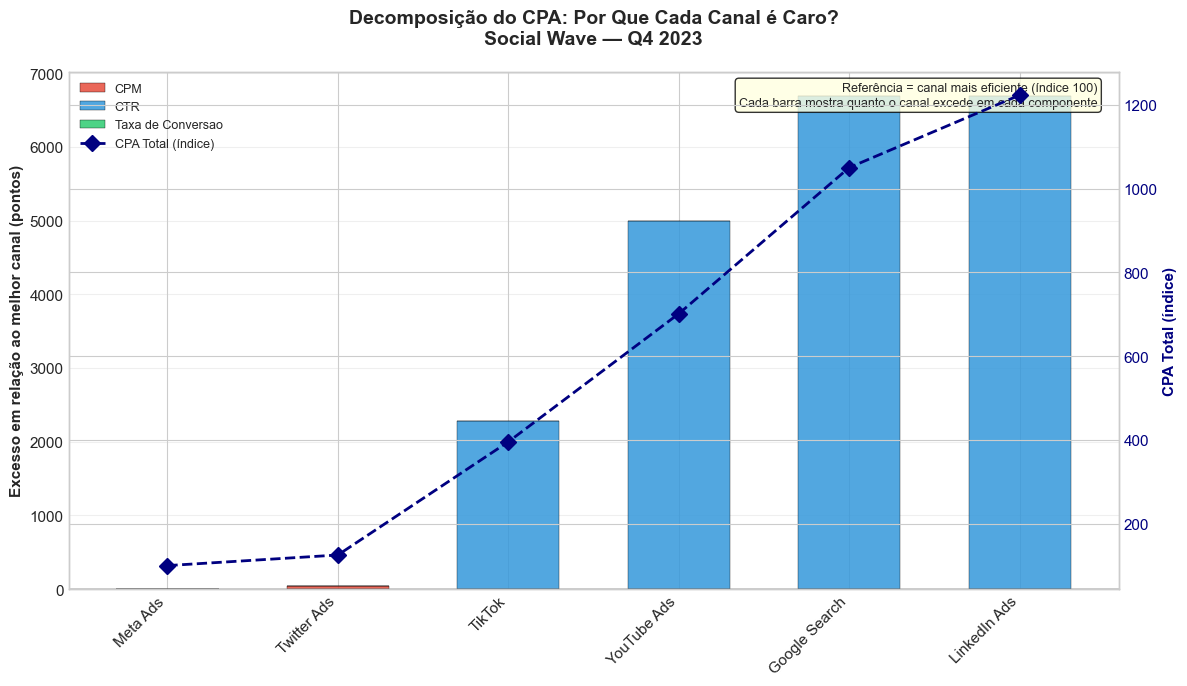


💡 INTERPRETAÇÃO

📊 Como ler este gráfico:
   • Linha tracejada azul = CPA total do canal (índice)
   • Barras coloridas = quanto cada componente contribui para o excesso de CPA

   🟥 Vermelho (CPM) = custo de alcance alto
   🟦 Azul (CTR) = atração baixa (criativo ruim)
   🟩 Verde (Taxa de Conversão) = conversão baixa (landing page ruim)

💡 Exemplo: Se um canal tem CPA = 150 e a barra vermelha vale 30,
   significa que 30 pontos do excesso de CPA vêm do CPM caro.



In [4]:
print('=' * 60)
print('📊 GRÁFICO: DECOMPOSIÇÃO DO CPA')
print('=' * 60)

# ============================================================
# PREPARAR DADOS
# ============================================================

# Usar os índices calculados na célula anterior
# Reorganizar para o gráfico
dados_plot = componentes.set_index('Canal')[['Indice_CPM', 'Indice_CTR', 'Indice_Conversao', 'Indice_CPA']].copy()

# Ordenar por CPA (do mais eficiente para o menos)
dados_plot = dados_plot.sort_values('Indice_CPA')

# ============================================================
# CRIAR GRÁFICO DE BARRAS EMPILHADAS
# ============================================================

fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(dados_plot))
largura = 0.6

# Cores para cada componente
cores = {
    'Indice_CPM': '#e74c3c',      # Vermelho = custo (quanto maior, pior)
    'Indice_CTR': '#3498db',       # Azul = atração (quanto maior, pior)
    'Indice_Conversao': '#2ecc71'  # Verde = conversão (quanto maior, pior)
}

# Barras empilhadas
bottom = np.zeros(len(dados_plot))

for col, cor in cores.items():
    valores = dados_plot[col].values - 100  # Diferença em relação à referência (100)
    valores_positivos = np.where(valores > 0, valores, 0)
    
    ax.bar(
        x,
        valores_positivos,
        largura,
        bottom=bottom,
        label=col.replace('Indice_', '').replace('Conversao', 'Taxa de Conversao'),
        color=cor,
        edgecolor='black',
        linewidth=0.3,
        alpha=0.85
    )
    bottom += valores_positivos

# Linha de referência (100 = eficiência do melhor canal)
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)

# ============================================================
# ADICIONAR LINHA DO CPA TOTAL
# ============================================================

# Plotar o CPA total como pontos/linha
ax2 = ax.twinx()
ax2.plot(
    x,
    dados_plot['Indice_CPA'],
    color='navy',
    marker='D',
    markersize=8,
    linewidth=2,
    label='CPA Total (índice)',
    linestyle='--'
)

ax2.set_ylabel('CPA Total (índice)', fontsize=11, fontweight='bold', color='navy')
ax2.tick_params(axis='y', labelcolor='navy')

# ============================================================
# CONFIGURAR ESTILO
# ============================================================

ax.set_xticks(x)
ax.set_xticklabels(dados_plot.index, rotation=45, ha='right')
ax.set_ylabel('Excesso em relação ao melhor canal (pontos)', fontsize=11, fontweight='bold')
ax.set_xlabel('')

ax.set_title(
    'Decomposição do CPA: Por Que Cada Canal é Caro?\nSocial Wave — Q4 2023',
    fontsize=14,
    fontweight='bold',
    pad=20
)

# Legenda combinada
linhas1, rotulos1 = ax.get_legend_handles_labels()
linhas2, rotulos2 = ax2.get_legend_handles_labels()
ax.legend(linhas1 + linhas2, rotulos1 + rotulos2, loc='upper left', fontsize=9)

ax.grid(axis='y', alpha=0.3)

# Anotação explicativa
ax.text(
    0.98, 0.98,
    'Referência = canal mais eficiente (índice 100)\nCada barra mostra quanto o canal excede em cada componente',
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)

plt.tight_layout()

# ============================================================
# SALVAR FIGURA
# ============================================================

figura_path = r'C:\Users\ricar\Documents\projetos\social-wave-campaign-optimization\images\07_decomposicao_cpa.png'
plt.savefig(figura_path, dpi=150, bbox_inches='tight')
print(f'✅ Figura salva: {figura_path}')

# ============================================================
# EXIBIR
# ============================================================

plt.show()

print('\n' + '=' * 60)
print('💡 INTERPRETAÇÃO')
print('=' * 60)

print('''
📊 Como ler este gráfico:
   • Linha tracejada azul = CPA total do canal (índice)
   • Barras coloridas = quanto cada componente contribui para o excesso de CPA
   
   🟥 Vermelho (CPM) = custo de alcance alto
   🟦 Azul (CTR) = atração baixa (criativo ruim)
   🟩 Verde (Taxa de Conversão) = conversão baixa (landing page ruim)

💡 Exemplo: Se um canal tem CPA = 150 e a barra vermelha vale 30,
   significa que 30 pontos do excesso de CPA vêm do CPM caro.
''')

| Cor          | Componente        | Quando aparece grande          | Ação                            |
| ------------ | ----------------- | ------------------------------ | ------------------------------- |
| **Vermelho** | CPM               | Canal paga caro por alcance    | Renegociar ou mudar segmentação |
| **Azul**     | CTR               | Criativo não atrai cliques     | Testar novos anúncios           |
| **Verde**    | Taxa de Conversão | Tráfego chega mas não converte | Revisar landing page            |


## Análise de Sensibilidade

Responde a pergunta: "Se melhorarmos o CPM, o CTR ou a Taxa de Conversão de um canal, quanto o CPA cai?

Simula melhorias de 10%, 20% e 30% em cada componente para priorizar ações.

In [5]:
print('=' * 60)
print('📊 ANÁLISE DE SENSIBILIDADE')
print('=' * 60)

# ============================================================
# FUNÇÃO DE SIMULAÇÃO
# ============================================================

print('\n' + '-' * 60)
print('FUNÇÃO DE SIMULAÇÃO')
print('-' * 60)

def simular_cpa(cpm, ctr, taxa_conv, melhoria_cpm=0, melhoria_ctr=0, melhoria_conv=0):
    '''
    Simula CPA com melhorias percentuais em cada componente.
    
    melhoria_cpm: redução percentual no CPM (ex: 0.10 = 10% mais barato)
    melhoria_ctr: aumento percentual no CTR (ex: 0.10 = 10% melhor)
    melhoria_conv: aumento percentual na Taxa de Conversao (ex: 0.10 = 10% melhor)
    '''
    cpm_novo = cpm * (1 - melhoria_cpm)
    ctr_novo = ctr * (1 + melhoria_ctr)
    conv_novo = taxa_conv * (1 + melhoria_conv)
    
    cpa_novo = (cpm_novo / (ctr_novo * conv_novo)) * 100000
    return cpa_novo

print('✅ Funcao de simulacao criada')
print('   Formula: CPA = CPM / (CTR * Taxa_Conversao) * 100000')
print('   Melhorias: reducao de CPM, aumento de CTR, aumento de Taxa_Conversao')

# ============================================================
# CENÁRIOS DE MELHORIA
# ============================================================

print('\n' + '-' * 60)
print('CENÁRIOS DE MELHORIA')
print('-' * 60)

# Cenários: 10%, 20%, 30% de melhoria em cada componente
cenarios = [0.10, 0.20, 0.30]

# Canal menos eficiente (onde a melhoria mais importa)
canal_alvo = resumo['CPA'].idxmax()
row_alvo = resumo.loc[canal_alvo]

print(f'\n🎯 Canal analisado: {canal_alvo} (CPA atual: ${row_alvo['CPA']:.2f})')
print(f'   CPM: ${row_alvo['CPM']:.2f} | CTR: {row_alvo['CTR']:.2f}% | Taxa de Conversao: {row_alvo['Taxa_Conversao']:.2f}%')

# Tabela de resultados
resultados = []

for cenario in cenarios:
    # Melhorar apenas CPM
    cpa_cpm = simular_cpa(row_alvo['CPM'], row_alvo['CTR'], row_alvo['Taxa_Conversao'], 
                          melhoria_cpm=cenario)
    reducao_cpm = ((row_alvo['CPA'] - cpa_cpm) / row_alvo['CPA'] * 100)
    
    # Melhorar apenas CTR
    cpa_ctr = simular_cpa(row_alvo['CPM'], row_alvo['CTR'], row_alvo['Taxa_Conversao'], 
                          melhoria_ctr=cenario)
    reducao_ctr = ((row_alvo['CPA'] - cpa_ctr) / row_alvo['CPA'] * 100)
    
    # Melhorar apenas Conversao
    cpa_conv = simular_cpa(row_alvo['CPM'], row_alvo['CTR'], row_alvo['Taxa_Conversao'], 
                           melhoria_conv=cenario)
    reducao_conv = ((row_alvo['CPA'] - cpa_conv) / row_alvo['CPA'] * 100)
    
    resultados.append({
        'Cenario': f'{cenario*100:.0f}%',
        'CPA_Atual': row_alvo['CPA'],
        'CPA_CPM': cpa_cpm,
        'Reducao_CPM': reducao_cpm,
        'CPA_CTR': cpa_ctr,
        'Reducao_CTR': reducao_ctr,
        'CPA_Conv': cpa_conv,
        'Reducao_Conv': reducao_conv
    })

df_resultados = pd.DataFrame(resultados)

print(f'\n📊 RESULTADOS: Impacto de melhorias em {canal_alvo}')
print(f'\n{'Cenario':<10} {'CPA Atual':>10} {'CPA (CPM)':>10} {'Reducao':>10} {'CPA (CTR)':>10} {'Reducao':>10} {'CPA (Conv)':>10} {'Reducao':>10}')
print('-' * 95)

for _, r in df_resultados.iterrows():
    print(f'{r['Cenario']:<10} ${r['CPA_Atual']:>8.2f} ${r['CPA_CPM']:>8.2f} {r['Reducao_CPM']:>8.1f}% ${r['CPA_CTR']:>8.2f} {r['Reducao_CTR']:>8.1f}% ${r['CPA_Conv']:>8.2f} {r['Reducao_Conv']:>8.1f}%')

# ============================================================
# PRIORIDADE DE AÇÃO
# ============================================================

print('\n' + '=' * 60)
print('🎯 PRIORIDADE DE AÇÃO')
print('=' * 60)

# Calcular elasticidade (redução de CPA por 1% de melhoria em cada componente)
elasticidade_cpm = df_resultados.iloc[0]['Reducao_CPM'] / 10
elasticidade_ctr = df_resultados.iloc[0]['Reducao_CTR'] / 10
elasticidade_conv = df_resultados.iloc[0]['Reducao_Conv'] / 10

print(f'\n📊 Elasticidade (reducao de CPA por 1% de melhoria):')
print(f'   • CPM: {elasticidade_cpm:.2f}% de reducao no CPA')
print(f'   • CTR: {elasticidade_ctr:.2f}% de reducao no CPA')
print(f'   • Taxa de Conversao: {elasticidade_conv:.2f}% de reducao no CPA')

# Identificar maior impacto
elasticidades = {
    'Reduzir CPM': elasticidade_cpm,
    'Melhorar CTR': elasticidade_ctr,
    'Melhorar Taxa de Conversao': elasticidade_conv
}

melhor_acao = max(elasticidades, key=elasticidades.get)
maior_impacto = elasticidades[melhor_acao]

print(f'\n🏆 MAIOR IMPACTO: {melhor_acao}')
print(f'   {maior_impacto:.2f}% de reducao no CPA para cada 1% de melhoria')

# ============================================================
# SIMULAÇÃO PARA TODOS OS CANAIS
# ============================================================

print('\n' + '-' * 60)
print('MELHOR AÇÃO POR CANAL')
print('-' * 60)

print(f'\n{'Canal':<18} {'CPA Atual':>10} {'Melhor Acao':>25} {'CPA Simulado':>12} {'Reducao':>10}')
print('-' * 80)

for canal in resumo.index:
    row = resumo.loc[canal]
    
    # Testar as 3 acoes com 20% de melhoria
    cpa_cpm = simular_cpa(row['CPM'], row['CTR'], row['Taxa_Conversao'], melhoria_cpm=0.20)
    cpa_ctr = simular_cpa(row['CPM'], row['CTR'], row['Taxa_Conversao'], melhoria_ctr=0.20)
    cpa_conv = simular_cpa(row['CPM'], row['CTR'], row['Taxa_Conversao'], melhoria_conv=0.20)
    
    # Melhor resultado
    cpas = {'Reduzir CPM': cpa_cpm, 'Melhorar CTR': cpa_ctr, 'Melhorar Conversao': cpa_conv}
    melhor = min(cpas, key=cpas.get)
    cpa_melhor = cpas[melhor]
    reducao = ((row['CPA'] - cpa_melhor) / row['CPA'] * 100)
    
    print(f'{canal:<18} ${row['CPA']:>8.2f} {melhor:>25} ${cpa_melhor:>10.2f} {reducao:>9.1f}%')

print('\n' + '=' * 60)
print('🚀 ANÁLISE DE SENSIBILIDADE COMPLETA!')
print('=' * 60)

📊 ANÁLISE DE SENSIBILIDADE

------------------------------------------------------------
FUNÇÃO DE SIMULAÇÃO
------------------------------------------------------------
✅ Funcao de simulacao criada
   Formula: CPA = CPM / (CTR * Taxa_Conversao) * 100000
   Melhorias: reducao de CPM, aumento de CTR, aumento de Taxa_Conversao

------------------------------------------------------------
CENÁRIOS DE MELHORIA
------------------------------------------------------------

🎯 Canal analisado: LinkedIn Ads (CPA atual: $47.47)
   CPM: $2.12 | CTR: 0.21% | Taxa de Conversao: 2.11%

📊 RESULTADOS: Impacto de melhorias em LinkedIn Ads

Cenario     CPA Atual  CPA (CPM)    Reducao  CPA (CTR)    Reducao CPA (Conv)    Reducao
-----------------------------------------------------------------------------------------------
10%        $   47.47 $430602.57 -907004.6% $434952.09 -916167.3% $434952.09 -916167.3%
20%        $   47.47 $382757.84 -806215.2% $398706.09 -839811.7% $398706.09 -839811.7%
30%        

| Métrica                     | Significado                               | Uso                              |
| --------------------------- | ----------------------------------------- | -------------------------------- |
| **Elasticidade**            | Quanto o CPA cai para cada 1% de melhoria | Priorizar ação com maior retorno |
| **Melhor ação por canal**   | Qual componente melhorar em cada canal    | Plano de ação personalizado      |
| **Redução de CPA simulada** | CPA após melhoria de 20%                  | Estimativa de ganho potencial    |
